In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

PROJECT_ROOT = Path("../..").resolve()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "pairs.csv"

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)
print("Data exists:", DATA_PATH.exists())


Project root: C:\Users\sshab\Documents\School\DSCI471\DSCI471_Final_Proj
Data path: C:\Users\sshab\Documents\School\DSCI471\DSCI471_Final_Proj\data\processed\products.csv
Data exists: True


In [2]:
df = pd.read_csv(DATA_PATH)

print("Dataframe shape:", df.shape)
print("Dataframe columns:", df.columns)
print("Dataframe head:\n", df.head())

Dataframe shape: (5000, 11)
Dataframe columns: Index(['id', 'image_path', 'product_text', 'gender', 'masterCategory',
       'subCategory', 'articleType', 'baseColour', 'season', 'usage',
       'productDisplayName'],
      dtype='str')
Dataframe head:
       id                                 image_path  \
0  16947  data\raw\fashion-dataset\images\16947.jpg   
1  40524  data\raw\fashion-dataset\images\40524.jpg   
2  36313  data\raw\fashion-dataset\images\36313.jpg   
3  44188  data\raw\fashion-dataset\images\44188.jpg   
4  33859  data\raw\fashion-dataset\images\33859.jpg   

                                        product_text gender masterCategory  \
0  Women Accessories Eyewear Sunglasses Brown Win...  Women    Accessories   
1  Men Accessories Watches Watches White Winter C...    Men    Accessories   
2  Boys Apparel Topwear Tshirts Yellow Summer Cas...   Boys        Apparel   
3  Women Footwear Flip Flops Flip Flops Black Win...  Women       Footwear   
4  Women Footwear Flip Fl

In [3]:
print("Columns:")
for col in df.columns:
    print(f"- {col}")

Columns:
- id
- image_path
- product_text
- gender
- masterCategory
- subCategory
- articleType
- baseColour
- season
- usage
- productDisplayName


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   id                  5000 non-null   int64
 1   image_path          5000 non-null   str  
 2   product_text        5000 non-null   str  
 3   gender              5000 non-null   str  
 4   masterCategory      5000 non-null   str  
 5   subCategory         5000 non-null   str  
 6   articleType         5000 non-null   str  
 7   baseColour          4999 non-null   str  
 8   season              4998 non-null   str  
 9   usage               4967 non-null   str  
 10  productDisplayName  4999 non-null   str  
dtypes: int64(1), str(10)
memory usage: 429.8 KB


In [5]:
missing = df.isna().sum().sort_values(ascending=False)
missing

usage                 33
season                 2
productDisplayName     1
baseColour             1
product_text           0
id                     0
image_path             0
articleType            0
subCategory            0
masterCategory         0
gender                 0
dtype: int64

In [6]:
for i in range(5):
    print(f"Example {i+1}:")
    print(df.iloc[i]["product_text"])
    print("-" * 80)

Example 1:
Women Accessories Eyewear Sunglasses Brown Winter Casual Image Women Classic Eyewear Brown Sunglasses
--------------------------------------------------------------------------------
Example 2:
Men Accessories Watches Watches White Winter Casual Titan Men White Chronograph Watch
--------------------------------------------------------------------------------
Example 3:
Boys Apparel Topwear Tshirts Yellow Summer Casual Mr.Men Boys Blazing Yellow T-shirt
--------------------------------------------------------------------------------
Example 4:
Women Footwear Flip Flops Flip Flops Black Winter Casual iPanema Women Black Flip Flops
--------------------------------------------------------------------------------
Example 5:
Women Footwear Flip Flops Flip Flops Pink Summer Casual Puma Women Lucie Pink Flip Flops
--------------------------------------------------------------------------------


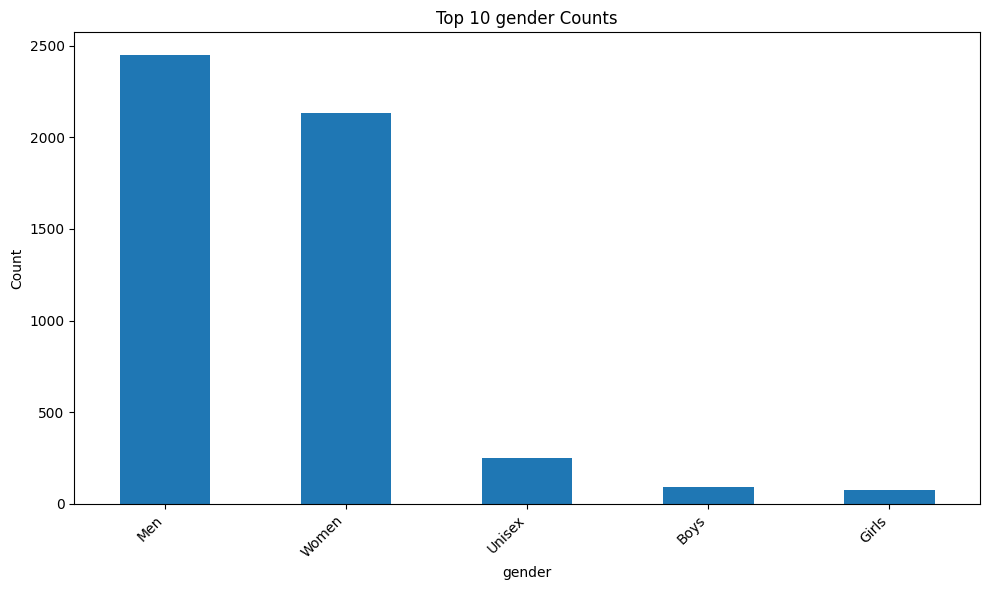

In [8]:
def plot_top_counts(column, top_n=10):
    counts = df[column].value_counts().head(top_n)
    plt.figure(figsize=(10, 6))
    counts.plot(kind="bar")
    plt.title(f"Top {top_n} {column} Counts")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

plot_top_counts("gender")

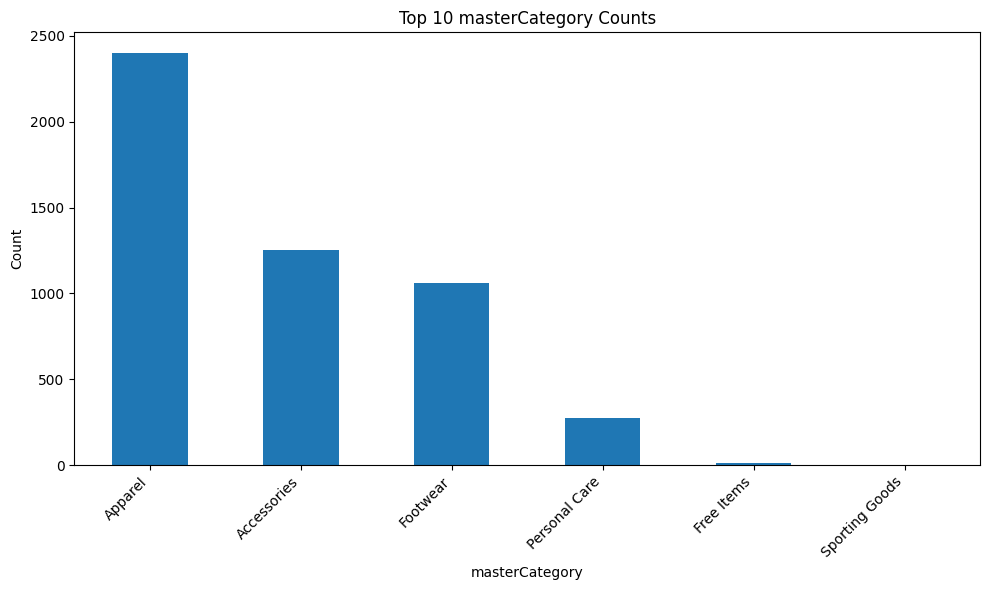

In [11]:
plot_top_counts("masterCategory")

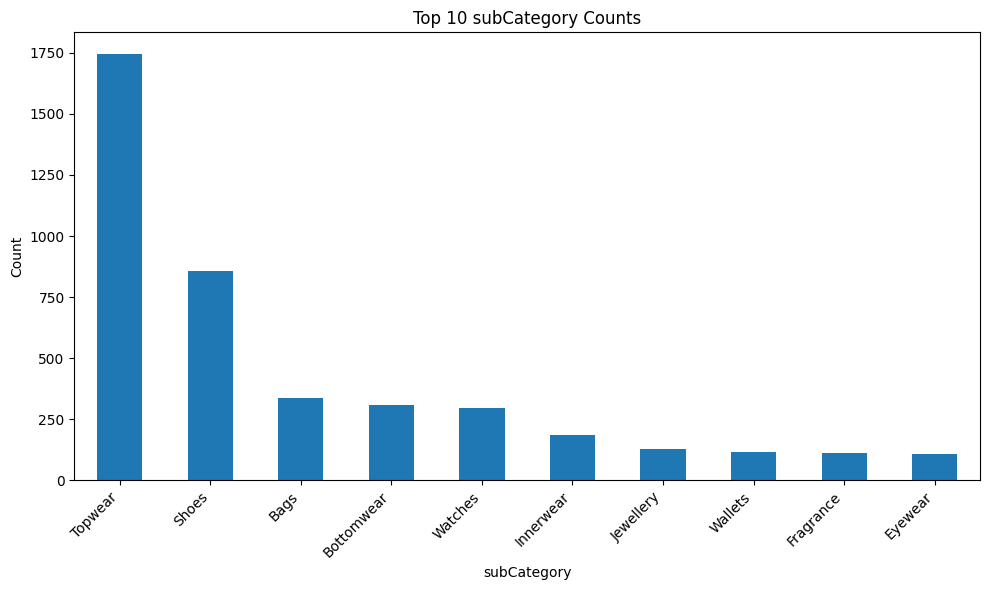

In [12]:
plot_top_counts("subCategory")

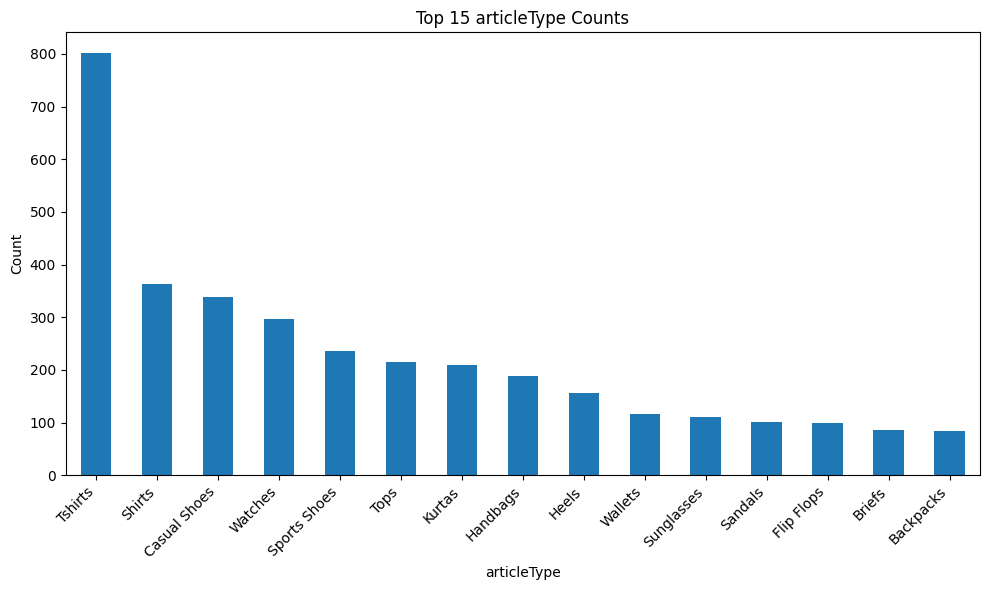

In [13]:
plot_top_counts("articleType", top_n=15)

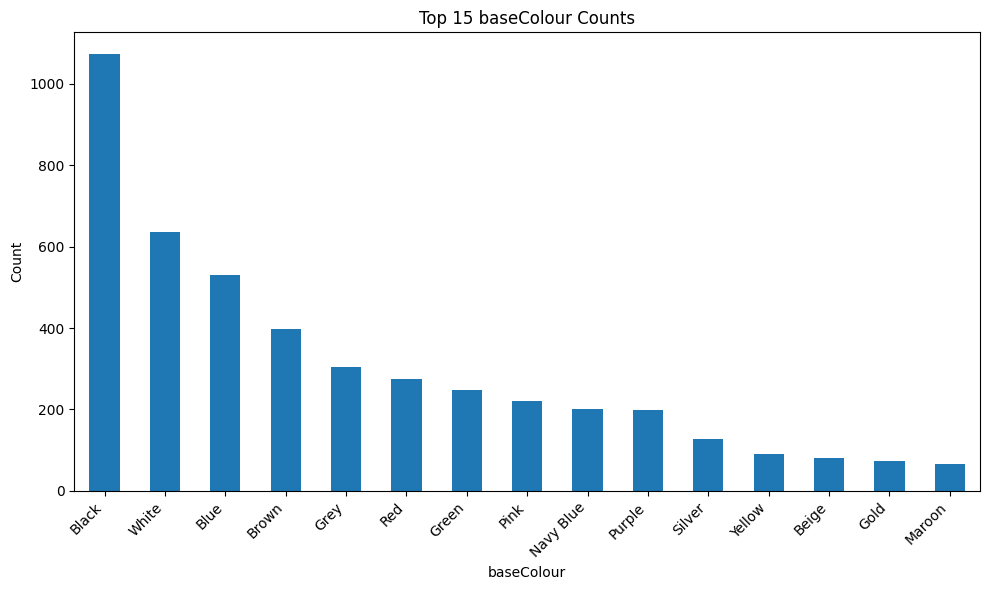

In [14]:
plot_top_counts("baseColour", top_n=15)


In [15]:
def show_product(row):
    image_path = PROJECT_ROOT / row["image_path"]

    if not image_path.exists():
        print("Missing image:", image_path)
        return

    img = Image.open(image_path)

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title(row.get("productDisplayName", "No product name"))
    plt.show()

    print("ID:", row["id"])
    print("Text:", row["product_text"])
    print("Gender:", row.get("gender"))
    print("Category:", row.get("masterCategory"), ">", row.get("subCategory"), ">", row.get("articleType"))
    print("Color:", row.get("baseColour"))
    print("Season:", row.get("season"))
    print("Usage:", row.get("usage"))


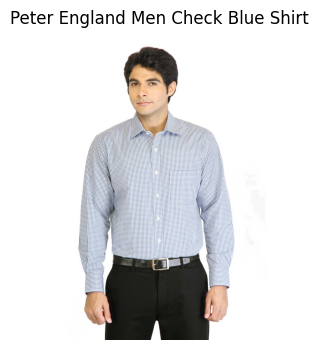

ID: 16343
Text: Men Apparel Topwear Shirts Blue Fall Formal Peter England Men Check Blue Shirt
Gender: Men
Category: Apparel > Topwear > Shirts
Color: Blue
Season: Fall
Usage: Formal


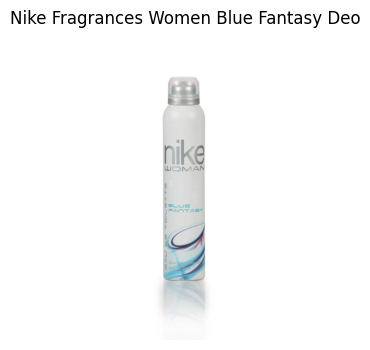

ID: 23609
Text: Women Personal Care Fragrance Deodorant White Spring Casual Nike Fragrances Women Blue Fantasy Deo
Gender: Women
Category: Personal Care > Fragrance > Deodorant
Color: White
Season: Spring
Usage: Casual


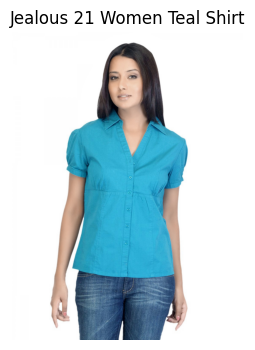

ID: 26958
Text: Women Apparel Topwear Shirts Teal Summer Casual Jealous 21 Women Teal Shirt
Gender: Women
Category: Apparel > Topwear > Shirts
Color: Teal
Season: Summer
Usage: Casual


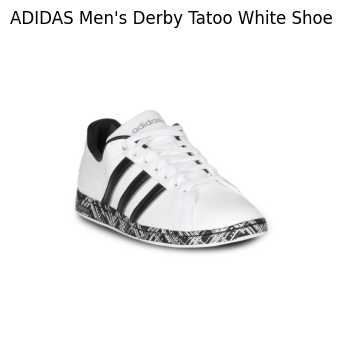

ID: 5936
Text: Men Footwear Shoes Casual Shoes White Summer Casual ADIDAS Men's Derby Tatoo White Shoe
Gender: Men
Category: Footwear > Shoes > Casual Shoes
Color: White
Season: Summer
Usage: Casual


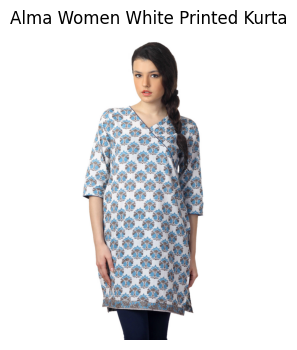

ID: 42684
Text: Women Apparel Topwear Kurtas White Summer Ethnic Alma Women White Printed Kurta
Gender: Women
Category: Apparel > Topwear > Kurtas
Color: White
Season: Summer
Usage: Ethnic


In [17]:
sample = df.sample(5, random_state=42)

for _, row in sample.iterrows():
    show_product(row)
    print("=" * 80)


Found 801 products for articleType = Tshirts


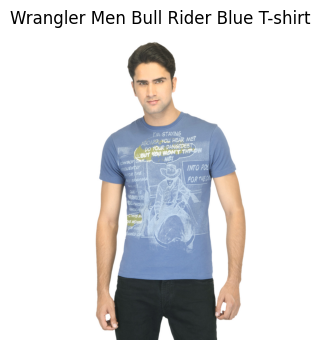

ID: 29308
Text: Men Apparel Topwear Tshirts Blue Summer Casual Wrangler Men Bull Rider Blue T-shirt
Gender: Men
Category: Apparel > Topwear > Tshirts
Color: Blue
Season: Summer
Usage: Casual


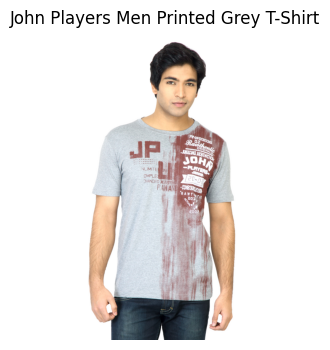

ID: 22339
Text: Men Apparel Topwear Tshirts Grey Fall Casual John Players Men Printed Grey T-Shirt
Gender: Men
Category: Apparel > Topwear > Tshirts
Color: Grey
Season: Fall
Usage: Casual


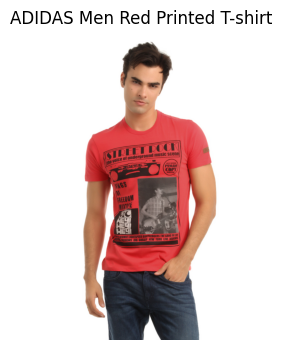

ID: 46398
Text: Men Apparel Topwear Tshirts Red Winter Casual ADIDAS Men Red Printed T-shirt
Gender: Men
Category: Apparel > Topwear > Tshirts
Color: Red
Season: Winter
Usage: Casual


In [18]:
def show_examples_by_article_type(article_type, n=5):
    subset = df[df["articleType"].astype(str).str.lower() == article_type.lower()]

    print(f"Found {len(subset)} products for articleType = {article_type}")

    if len(subset) == 0:
        return

    sample = subset.sample(min(n, len(subset)), random_state=42)

    for _, row in sample.iterrows():
        show_product(row)
        print("=" * 100)

show_examples_by_article_type("Tshirts", n=3)


In [22]:
show_examples_by_article_type("Shoes", n=3)


Found 0 products for articleType = Shoes


Found 51 products for articleType = Dresses


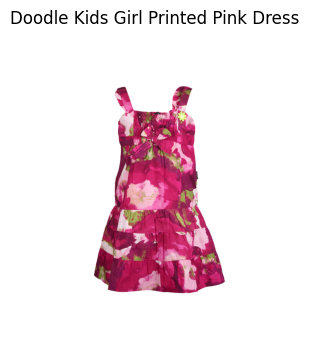

ID: 33504
Text: Women Apparel Dress Dresses Pink Summer Casual Doodle Kids Girl Printed Pink Dress
Gender: Women
Category: Apparel > Dress > Dresses
Color: Pink
Season: Summer
Usage: Casual


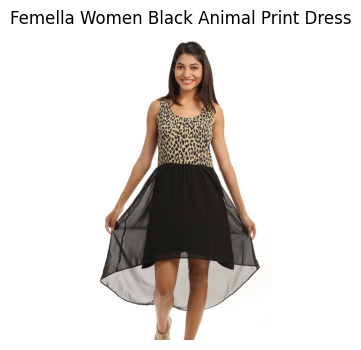

ID: 47676
Text: Women Apparel Dress Dresses Black Summer Casual Femella Women Black Animal Print Dress
Gender: Women
Category: Apparel > Dress > Dresses
Color: Black
Season: Summer
Usage: Casual


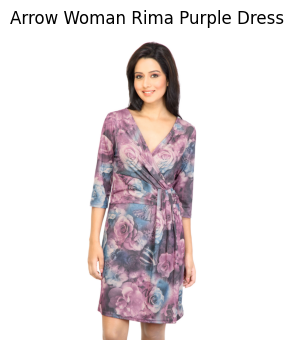

ID: 18735
Text: Women Apparel Dress Dresses Purple Fall Casual Arrow Woman Rima Purple Dress
Gender: Women
Category: Apparel > Dress > Dresses
Color: Purple
Season: Fall
Usage: Casual


In [20]:
show_examples_by_article_type("Dresses", n=3)


In [23]:
summary = {
    "Number of products": len(df),
    "Number of columns": len(df.columns),
    "Unique genders": df["gender"].nunique(),
    "Unique master categories": df["masterCategory"].nunique(),
    "Unique subcategories": df["subCategory"].nunique(),
    "Unique article types": df["articleType"].nunique(),
    "Unique base colors": df["baseColour"].nunique(),
}

summary_df = pd.DataFrame(summary.items(), columns=["Metric", "Value"])
summary_df

,Metric,Value
0,Number of products,5000
1,Number of columns,11
2,Unique genders,5
3,Unique master categories,6
4,Unique subcategories,39
5,Unique article types,117
6,Unique base colors,45


# Observations

Fill in this later